<a href="https://colab.research.google.com/github/VikaBilyk/numeric_methods/blob/main/numeric_method_simple_iteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Введіть мінімальне значення інтервалу: -1
Введіть максимальне значення інтервалу: -0.5
Введіть початкове наближення x0: -0.6
Введіть точність: 0.0001

Метод простої ітерації

Індекс     Значення x           f(x)                 Точність            
0          -0.6                 -1.2159999999999975  -0.6000000000000000
1          -0.5723636363636364  0.35249227472877465  0.0276363636363636
2          -0.580374824425654   -0.1003321603213223  0.0080111880620176
3          -0.5780945480547148  0.0287114922081102   0.0022802763709392
4          -0.5787470819685355  -0.00820374010057634 0.0006525339138207
5          -0.578560633329886   0.002345076028795745 0.0001864486386495
6          -0.5786139305123587  -0.0006702672517633346 0.0000532971824726

q (фактор збіжності): 0.5227
delta (максимальна відстань між x0 та межами інтервалу): 0.4000
Очікувана кількість ітерацій: 10
Кількість ітерацій: Очікувано: 10, Отримано: 6


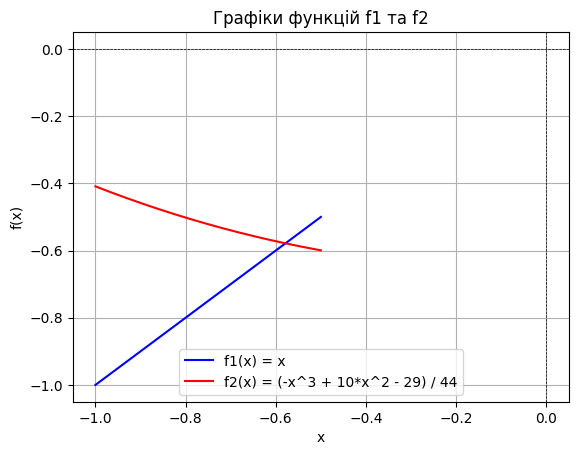

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Функція та її похідні
def f(x):
    return x**3 - 10*x**2 + 44*x + 29

def phi(x):
    return (-x**3 + 10*x**2 - 29) / 44

def phi_prime(x):
    return (5*x)/11 - (3*x**2)/44

# Метод простої ітерації
def simple_iteration_method(x0, epsilon, max_iterations=1000):
    x_current = x0
    for i in range(max_iterations):
        x_next = phi(x_current)
        if abs(x_next - x_current) < epsilon:
            return x_next, i + 1
        x_current = x_next
    return None, max_iterations

# Виведення таблиці результатів
def print_table_simple_iteration(x_vals, n_iterations, q, delta):
    print(f"\n{'Індекс':<10} {'Значення x':<20} {'f(x)':<20} {'Точність':<20}")
    print("=" * 70)

    for i in range(len(x_vals)):
        e = abs(x_vals[i] - x_vals[i - 1]) if i > 0 else x_vals[i]
        f_val = f(x_vals[i])
        print(f"{i:<10} {x_vals[i]:<20} {f_val:<20} {e:.16f}")

    # Виведення результатів
    print(f"\nq (фактор збіжності): {q:.4f}")
    print(f"delta (максимальна відстань між x0 та межами інтервалу): {delta:.4f}")
    print(f"Очікувана кількість ітерацій: {n_iterations}")

# Обчислення інтервалу та перевірка
def calculate_interval(interval, x0):
    x_min, x_max = interval
    if x0 < x_min or x0 > x_max:
        x0 = (x_min + x_max) / 2
        print(f"x0 поза діапазоном, змінено на {x0}")
    return x_min, x_max, x0

# Обчислення кількості ітерацій
def calculate_iterations(delta, accuracy, q):
    primary_calc = math.log(abs(delta / accuracy)) / math.log(1 / q)
    return math.ceil(math.log2(primary_calc + 1))

# Виведення методу простої ітерації
def simple_iteration_solve(interval, x0, epsilon):
    x_min, x_max = interval
    x_values = np.linspace(x_min, x_max, 50)
    q = max(np.abs([phi_prime(x) for x in x_values]))

    delta = max(abs(x_max - x0), abs(x_min - x0))

    if abs(phi(x0) - x0) <= (1 - q) * delta:
        steps = math.floor((math.log(abs(phi(x0) - x0) / ((1 - q) * epsilon)) / math.log(1 / q))) + 1
        root, steps_c = simple_iteration_method(x0, epsilon)

        x_vals = [x0]
        for _ in range(steps_c):
            x_vals.append(phi(x_vals[-1]))
        print_table_simple_iteration(x_vals, steps, q, delta)
        print(f"Кількість ітерацій: Очікувано: {steps}, Отримано: {steps_c}")
    else:
        print("Умова збіжності для простої ітерації не виконується.")

# Введення параметрів користувачем
x_min = float(input("Введіть мінімальне значення інтервалу: "))
x_max = float(input("Введіть максимальне значення інтервалу: "))
x0 = float(input("Введіть початкове наближення x0: "))
epsilon = float(input("Введіть точність: "))

# Виконуємо методи
print("\nМетод простої ітерації")
simple_iteration_solve((x_min, x_max), x0, epsilon)

# Графік функцій
x_range = np.linspace(x_min, x_max, 400)
f1 = x_range
f2 = phi(x_range)

plt.plot(x_range, f1, label='f1(x) = x', color='blue')
plt.plot(x_range, f2, label='f2(x) = (-x^3 + 10*x^2 - 29) / 44', color='red')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title('Графіки функцій f1 та f2')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid()
plt.show()
